In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Pandas version:", pd.__version__)

Pandas version: 3.0.6


In [5]:
file_path = "Hospital_General_Information.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Dataset loaded successfully!
Rows: 5419
Columns: 38


In [6]:
df.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,1,9,1,NaN,15,15,NaN,10,10,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,1,8,0,NaN,15,15,NaN,10,10,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,1,8,0,NaN,15,15,NaN,10,9,NaN
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,0,3,2,NaN,15,5,NaN,10,7,NaN
4,010011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,JEFFERSON,(205) 838-3122,Acute Care Hospitals,Voluntary non-profit - Private,...,1,5,2,29.0,15,10,29.0,10,7,29.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5419 entries, 0 to 5418
Data columns (total 38 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Facility ID                                       5419 non-null   str    
 1   Facility Name                                     5419 non-null   str    
 2   Address                                           5419 non-null   str    
 3   City/Town                                         5419 non-null   str    
 4   State                                             5419 non-null   str    
 5   ZIP Code                                          5419 non-null   int64  
 6   County/Parish                                     5419 non-null   str    
 7   Telephone Number                                  5419 non-null   str    
 8   Hospital Type                                     5419 non-null   str    
 9   Hospital Ownership            

In [8]:
df["Hospital overall rating"].value_counts(dropna=False)

Hospital overall rating
Not Available    2245
3                 985
4                 946
2                 661
5                 384
1                 198
Name: count, dtype: int64

In [9]:
df["MORT Group Measure Count"].value_counts(dropna=False)


MORT Group Measure Count
8                4569
Not Available     850
Name: count, dtype: int64

In [10]:
df["READM Group Measure Count"].value_counts(dropna=False)


READM Group Measure Count
11               4569
Not Available     850
Name: count, dtype: int64

In [11]:
df.duplicated().sum()


np.int64(0)

In [12]:
df["Facility ID"].duplicated().sum()


np.int64(0)

In [13]:
df_clean = df.copy()

print("Raw dataset:", df.shape)
print("Working copy:", df_clean.shape)

Raw dataset: (5419, 38)
Working copy: (5419, 38)


In [15]:
df_clean = df.copy()

print("Raw dataset:", df.shape)
print("Working copy:", df_clean.shape)

Raw dataset: (5419, 38)
Working copy: (5419, 38)


In [16]:
not_available_counts = (df_clean == "Not Available").sum()

not_available_counts[not_available_counts > 0].sort_values(ascending=False)

Hospital overall rating                  2245
Count of Safety Measures No Different    2075
Count of Safety Measures Worse           2075
Count of Facility Safety Measures        2075
Count of Safety Measures Better          2075
Count of Facility Pt Exp Measures        1955
Count of Facility MORT Measures          1323
Count of MORT Measures Better            1323
Count of MORT Measures Worse             1323
Count of MORT Measures No Different      1323
Count of READM Measures Worse            1155
Count of Facility READM Measures         1155
Count of READM Measures No Different     1155
Count of READM Measures Better           1155
Count of Facility TE Measures             919
MORT Group Measure Count                  850
READM Group Measure Count                 850
Safety Group Measure Count                850
Pt Exp Group Measure Count                850
TE Group Measure Count                    850
dtype: int64

In [17]:
numeric_candidates = [
    "Hospital overall rating",
    "MORT Group Measure Count",
    "Count of Facility MORT Measures",
    "Count of MORT Measures Better",
    "Count of MORT Measures No Different",
    "Count of MORT Measures Worse",
    "Safety Group Measure Count",
    "Count of Facility Safety Measures",
    "Count of Safety Measures Better",
    "Count of Safety Measures No Different",
    "Count of Safety Measures Worse",
    "READM Group Measure Count",
    "Count of Facility READM Measures",
    "Count of READM Measures Better",
    "Count of READM Measures No Different",
    "Count of READM Measures Worse",
    "Pt Exp Group Measure Count",
    "Count of Facility Pt Exp Measures",
    "TE Group Measure Count",
    "Count of Facility TE Measures"
]

df_clean[numeric_candidates].head()

,Hospital overall rating,MORT Group Measure Count,Count of Facility MORT Measures,Count of MORT Measures Better,Count of MORT Measures No Different,Count of MORT Measures Worse,Safety Group Measure Count,Count of Facility Safety Measures,Count of Safety Measures Better,Count of Safety Measures No Different,Count of Safety Measures Worse,READM Group Measure Count,Count of Facility READM Measures,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,TE Group Measure Count,Count of Facility TE Measures
0,4,8,8,0,8,0,8,7,3,4,0,11,11,1,9,1,15,15,10,10
1,3,8,6,0,5,1,8,7,0,7,0,11,9,1,8,0,15,15,10,10
2,2,8,8,0,5,3,8,8,4,4,0,11,9,1,8,0,15,15,10,9
3,1,8,4,0,3,1,8,2,0,2,0,11,5,0,3,2,15,5,10,7
4,3,8,8,0,8,0,8,7,1,6,0,11,8,1,5,2,15,10,10,7


In [19]:
for col in numeric_candidates:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print("Conversion completed successfully.")

Conversion completed successfully.


In [20]:
df_clean[numeric_candidates].dtypes

Hospital overall rating                  float64
MORT Group Measure Count                 float64
Count of Facility MORT Measures          float64
Count of MORT Measures Better            float64
Count of MORT Measures No Different      float64
Count of MORT Measures Worse             float64
Safety Group Measure Count               float64
Count of Facility Safety Measures        float64
Count of Safety Measures Better          float64
Count of Safety Measures No Different    float64
Count of Safety Measures Worse           float64
READM Group Measure Count                float64
Count of Facility READM Measures         float64
Count of READM Measures Better           float64
Count of READM Measures No Different     float64
Count of READM Measures Worse            float64
Pt Exp Group Measure Count               float64
Count of Facility Pt Exp Measures        float64
TE Group Measure Count                   float64
Count of Facility TE Measures            float64
dtype: object

In [21]:
df_clean["Hospital overall rating"].value_counts(
    dropna=False
).sort_index()

Hospital overall rating
1.0     198
2.0     661
3.0     985
4.0     946
5.0     384
NaN    2245
Name: count, dtype: int64

In [22]:
df_clean["MORT Group Measure Count"].value_counts(
    dropna=False
).sort_index()

MORT Group Measure Count
8.0    4569
NaN     850
Name: count, dtype: int64

In [23]:
df_clean["ZIP Code"] = (
    df_clean["ZIP Code"]
    .astype(str)
    .str.zfill(5)
)

print("ZIP Code type:", df_clean["ZIP Code"].dtype)
df_clean["ZIP Code"].head(10)

ZIP Code type: str


0    36301
1    35957
2    35630
3    36467
4    35235
5    35968
6    35007
7    35660
8    36360
9    35960
Name: ZIP Code, dtype: str

In [24]:
missing_values = df_clean.isna().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

TE Group Footnote                                   4411
READM Group Footnote                                4196
MORT Group Footnote                                 4023
Pt Exp Group Footnote                               3403
Safety Group Footnote                               3270
Meets criteria for birthing friendly designation    3156
Hospital overall rating footnote                    3103
Hospital overall rating                             2245
Count of Facility Safety Measures                   2075
Count of Safety Measures Better                     2075
Count of Safety Measures No Different               2075
Count of Safety Measures Worse                      2075
Count of Facility Pt Exp Measures                   1955
Count of MORT Measures Better                       1323
Count of Facility MORT Measures                     1323
Count of MORT Measures No Different                 1323
Count of MORT Measures Worse                        1323
Count of READM Measures Worse  

In [25]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Duplicate rows:", df_clean.duplicated().sum())
print("Duplicate Facility IDs:", df_clean["Facility ID"].duplicated().sum())
print("Missing Facility IDs:", df_clean["Facility ID"].isna().sum())
print("Missing Facility Names:", df_clean["Facility Name"].isna().sum())

Rows: 5419
Columns: 38
Duplicate rows: 0
Duplicate Facility IDs: 0
Missing Facility IDs: 0
Missing Facility Names: 0


In [26]:
df_clean["ZIP Code"].str.len().value_counts()

ZIP Code
5    5419
Name: count, dtype: int64

In [27]:
df_clean.to_csv(
    "Hospital_General_Information_Cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")
print("Final shape:", df_clean.shape)

Cleaned dataset saved successfully.
Final shape: (5419, 38)


In [28]:
for i, col in enumerate(df_clean.columns, start=1):
    print(f"{i}. {col}")

1. Facility ID
2. Facility Name
3. Address
4. City/Town
5. State
6. ZIP Code
7. County/Parish
8. Telephone Number
9. Hospital Type
10. Hospital Ownership
11. Emergency Services
12. Meets criteria for birthing friendly designation
13. Hospital overall rating
14. Hospital overall rating footnote
15. MORT Group Measure Count
16. Count of Facility MORT Measures
17. Count of MORT Measures Better
18. Count of MORT Measures No Different
19. Count of MORT Measures Worse
20. MORT Group Footnote
21. Safety Group Measure Count
22. Count of Facility Safety Measures
23. Count of Safety Measures Better
24. Count of Safety Measures No Different
25. Count of Safety Measures Worse
26. Safety Group Footnote
27. READM Group Measure Count
28. Count of Facility READM Measures
29. Count of READM Measures Better
30. Count of READM Measures No Different
31. Count of READM Measures Worse
32. READM Group Footnote
33. Pt Exp Group Measure Count
34. Count of Facility Pt Exp Measures
35. Pt Exp Group Footnote
36. 

In [29]:
analysis_columns = [
    "Facility ID",
    "Facility Name",
    "City/Town",
    "State",
    "ZIP Code",
    "County/Parish",
    "Hospital Type",
    "Hospital Ownership",
    "Emergency Services",
    "Meets criteria for birthing friendly designation",
    "Hospital overall rating",

    "MORT Group Measure Count",
    "Count of Facility MORT Measures",
    "Count of MORT Measures Better",
    "Count of MORT Measures No Different",
    "Count of MORT Measures Worse",

    "Safety Group Measure Count",
    "Count of Facility Safety Measures",
    "Count of Safety Measures Better",
    "Count of Safety Measures No Different",
    "Count of Safety Measures Worse",

    "READM Group Measure Count",
    "Count of Facility READM Measures",
    "Count of READM Measures Better",
    "Count of READM Measures No Different",
    "Count of READM Measures Worse",

    "Pt Exp Group Measure Count",
    "Count of Facility Pt Exp Measures",

    "TE Group Measure Count",
    "Count of Facility TE Measures"
]

df_analysis = df_clean[analysis_columns].copy()

print("Master cleaned dataset:", df_clean.shape)
print("Analysis dataset:", df_analysis.shape)

Master cleaned dataset: (5419, 38)
Analysis dataset: (5419, 30)


In [30]:
rating_labels = {
    1.0: "1 Star",
    2.0: "2 Stars",
    3.0: "3 Stars",
    4.0: "4 Stars",
    5.0: "5 Stars"
}

df_analysis["Rating Category"] = (
    df_analysis["Hospital overall rating"]
    .map(rating_labels)
    .fillna("Not Rated")
)

df_analysis["Rating Category"].value_counts()


Rating Category
Not Rated    2245
3 Stars       985
4 Stars       946
2 Stars       661
5 Stars       384
1 Star        198
Name: count, dtype: int64

In [31]:
def classify_performance(rating):
    if pd.isna(rating):
        return "Not Rated"
    elif rating >= 4:
        return "High Rated"
    elif rating == 3:
        return "Average Rated"
    else:
        return "Low Rated"


df_analysis["Performance Group"] = (
    df_analysis["Hospital overall rating"]
    .apply(classify_performance)
)

df_analysis["Performance Group"].value_counts()

Performance Group
Not Rated        2245
High Rated       1330
Average Rated     985
Low Rated         859
Name: count, dtype: int64

In [32]:
print("Analysis dataset shape:", df_analysis.shape)
print("Duplicate Facility IDs:", df_analysis["Facility ID"].duplicated().sum())

print("\nPerformance Group totals:")
print(df_analysis["Performance Group"].value_counts())

print("\nRating Category totals:")
print(df_analysis["Rating Category"].value_counts())

Analysis dataset shape: (5419, 32)
Duplicate Facility IDs: 0

Performance Group totals:
Performance Group
Not Rated        2245
High Rated       1330
Average Rated     985
Low Rated         859
Name: count, dtype: int64

Rating Category totals:
Rating Category
Not Rated    2245
3 Stars       985
4 Stars       946
2 Stars       661
5 Stars       384
1 Star        198
Name: count, dtype: int64


In [33]:
df_analysis.to_csv(
    "Hospital_Analysis_Ready.csv",
    index=False
)

print("Analysis-ready dataset saved successfully.")
print("Final shape:", df_analysis.shape)

Analysis-ready dataset saved successfully.
Final shape: (5419, 32)


## 5. exploratory Data Analysis (EDA)

In [35]:
print("Total hospitals:", len(df_analysis))
print("States/Territories:", df_analysis["State"].nunique())
print("Hospital types:", df_analysis["Hospital Type"].nunique())
print("Ownership categories:", df_analysis["Hospital Ownership"].nunique())

print("\nAverage hospital rating:")
print(round(df_analysis["Hospital overall rating"].mean(), 2))

print("\nMedian hospital rating:")
print(df_analysis["Hospital overall rating"].median())

print("\nHospitals with ratings:")
print(df_analysis["Hospital overall rating"].notna().sum())

print("\nHospitals without ratings:")
print(df_analysis["Hospital overall rating"].isna().sum())

Total hospitals: 5419
States/Territories: 56
Hospital types: 8
Ownership categories: 12

Average hospital rating:
3.21

Median hospital rating:
3.0

Hospitals with ratings:
3174

Hospitals without ratings:
2245


In [36]:
rating_distribution = (
    df_analysis["Rating Category"]
    .value_counts()
)

rating_distribution

Rating Category
Not Rated    2245
3 Stars       985
4 Stars       946
2 Stars       661
5 Stars       384
1 Star        198
Name: count, dtype: int64

In [37]:
hospital_type_counts = (
    df_analysis["Hospital Type"]
    .value_counts()
)

hospital_type_counts

Hospital Type
Acute Care Hospitals                    3107
Critical Access Hospitals               1382
Psychiatric                              624
Acute Care - Veterans Administration     132
Childrens                                 94
Rural Emergency Hospital                  43
Acute Care - Department of Defense        32
Long-term                                  5
Name: count, dtype: int64

In [38]:
ownership_counts = (
    df_analysis["Hospital Ownership"]
    .value_counts()
)

ownership_counts

Hospital Ownership
Voluntary non-profit - Private                 2322
Proprietary                                    1063
Government - Hospital District or Authority     512
Government - Local                              393
Voluntary non-profit - Other                    353
Voluntary non-profit - Church                   264
Government - State                              209
Veterans Health Administration                  132
Physician                                        80
Government - Federal                             42
Department of Defense                            32
Tribal                                           17
Name: count, dtype: int64

In [40]:
emergency_counts = (
    df_analysis["Emergency Services"]
    .value_counts()
)

emergency_counts

Emergency Services
Yes    4495
No      924
Name: count, dtype: int64

In [41]:
rating_by_type = (
    df_analysis
    .groupby("Hospital Type")["Hospital overall rating"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("mean", ascending=False)
)

rating_by_type

,count,mean,median
Hospital Type,,,
Acute Care - Veterans Administration,112,4.16,4.0
Critical Access Hospitals,399,3.22,3.0
Acute Care Hospitals,2663,3.16,3.0
Acute Care - Department of Defense,0,NaN,NaN
Childrens,0,NaN,NaN
Long-term,0,NaN,NaN
Psychiatric,0,NaN,NaN
Rural Emergency Hospital,0,NaN,NaN


In [42]:
rating_by_ownership = (
    df_analysis
    .groupby("Hospital Ownership")["Hospital overall rating"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
    .round(2)
)

rating_by_ownership

,count,mean,median
Hospital Ownership,,,
Tribal,3,4.33,5.0
Veterans Health Administration,112,4.16,4.0
Physician,18,3.67,3.5
Voluntary non-profit - Church,218,3.38,3.0
Voluntary non-profit - Private,1619,3.31,3.0
Voluntary non-profit - Other,246,3.30,3.0
Government - Local,179,2.92,3.0
Government - Hospital District or Authority,228,2.92,3.0
Government - State,38,2.87,3.0


In [43]:
state_summary = (
    df_analysis
    .groupby("State")
    .agg(
        Total_Hospitals=("Facility ID", "count"),
        Rated_Hospitals=("Hospital overall rating", "count"),
        Average_Rating=("Hospital overall rating", "mean"),
        Median_Rating=("Hospital overall rating", "median")
    )
)

state_summary["Percent_Rated"] = (
    state_summary["Rated_Hospitals"]
    / state_summary["Total_Hospitals"]
    * 100
)

state_summary = state_summary.sort_values(
    "Average_Rating",
    ascending=False
).round(2)

state_summary.head(15)


,Total_Hospitals,Rated_Hospitals,Average_Rating,Median_Rating,Percent_Rated
State,,,,,
UT,52,29,4.24,5.0,55.77
CO,96,49,3.96,4.0,51.04
SD,61,18,3.89,4.0,29.51
WI,140,86,3.78,4.0,61.43
MN,136,56,3.77,4.0,41.18
VA,96,76,3.68,4.0,79.17
OH,193,128,3.58,4.0,66.32
RI,13,11,3.55,4.0,84.62
ID,48,22,3.55,3.0,45.83


In [44]:
state_summary = (
    df_analysis
    .groupby("State")
    .agg(
        Total_Hospitals=("Facility ID", "count"),
        Rated_Hospitals=("Hospital overall rating", "count"),
        Average_Rating=("Hospital overall rating", "mean"),
        Median_Rating=("Hospital overall rating", "median")
    )
)

state_summary["Percent_Rated"] = (
    state_summary["Rated_Hospitals"]
    / state_summary["Total_Hospitals"]
    * 100
)

state_summary = state_summary.sort_values(
    "Average_Rating",
    ascending=False
).round(2)

state_summary.head(15)


,Total_Hospitals,Rated_Hospitals,Average_Rating,Median_Rating,Percent_Rated
State,,,,,
UT,52,29,4.24,5.0,55.77
CO,96,49,3.96,4.0,51.04
SD,61,18,3.89,4.0,29.51
WI,140,86,3.78,4.0,61.43
MN,136,56,3.77,4.0,41.18
VA,96,76,3.68,4.0,79.17
OH,193,128,3.58,4.0,66.32
RI,13,11,3.55,4.0,84.62
ID,48,22,3.55,3.0,45.83


In [45]:
corewell = michigan[
    michigan["Facility Name"]
    .str.contains("COREWELL", case=False, na=False)
].copy()

print("Corewell Health facilities found:", len(corewell))

corewell[
    [
        "Facility ID",
        "Facility Name",
        "City/Town",
        "Hospital overall rating",
        "Rating Category",
        "Performance Group"
    ]
].sort_values("Facility Name")

NameError: name 'michigan' is not defined

In [46]:
michigan = df_analysis[df_analysis["State"] == "MI"].copy()

print("Michigan hospitals:", len(michigan))
print(
    "Rated Michigan hospitals:",
    michigan["Hospital overall rating"].notna().sum()
)

print(
    "Average Michigan rating:",
    round(michigan["Hospital overall rating"].mean(), 2)
)

print(
    "Median Michigan rating:",
    michigan["Hospital overall rating"].median()
)

print("\nMichigan rating distribution:")
print(michigan["Rating Category"].value_counts())

Michigan hospitals: 149
Rated Michigan hospitals: 94
Average Michigan rating: 3.09
Median Michigan rating: 3.0

Michigan rating distribution:
Rating Category
Not Rated    55
3 Stars      30
4 Stars      27
2 Stars      19
5 Stars       9
1 Star        9
Name: count, dtype: int64


In [47]:
corewell = michigan[
    michigan["Facility Name"]
    .str.contains("COREWELL", case=False, na=False)
].copy()

print("Corewell Health facilities found:", len(corewell))

corewell[
    [
        "Facility ID",
        "Facility Name",
        "City/Town",
        "Hospital overall rating",
        "Rating Category",
        "Performance Group"
    ]
].sort_values("Facility Name")

Corewell Health facilities found: 9


,Facility ID,Facility Name,City/Town,Hospital overall rating,Rating Category,Performance Group
2372,230093,COREWELL HEALTH BIG RAPIDS HOSPITAL,BIG RAPIDS,3.0,3 Stars,Average Rated
2460,231338,COREWELL HEALTH GERBER HOSPITAL,FREMONT,5.0,5 Stars,High Rated
2380,230110,COREWELL HEALTH LUDINGTON HOSPITAL,LUDINGTON,4.0,4 Stars,High Rated
2461,231339,COREWELL HEALTH PENNOCK HOSPITAL,HASTINGS,3.0,3 Stars,Average Rated
2448,231323,COREWELL HEALTH REED CITY HOSPITAL,REED CITY,NaN,Not Rated,Not Rated
2397,230176,COREWELL HEALTH TRENTON HOSPITAL,TRENTON,3.0,3 Stars,Average Rated
2366,230078,COREWELL HEALTH WATERVLIET HOSPITAL,WATERVLIET,NaN,Not Rated,Not Rated
2389,230142,COREWELL HEALTH WAYNE HOSPITAL,WAYNE,2.0,2 Stars,Low Rated
2334,230003,COREWELL HEALTH ZEELAND HOSPITAL,ZEELAND,5.0,5 Stars,High Rated


In [48]:
legacy_search = michigan[
    michigan["Facility Name"].str.contains(
        "COREWELL|SPECTRUM|BEAUMONT",
        case=False,
        na=False,
        regex=True
    )
].copy()

print("Potential Corewell-related facilities:", len(legacy_search))

legacy_search[
    [
        "Facility ID",
        "Facility Name",
        "City/Town",
        "Hospital overall rating"
    ]
].sort_values("Facility Name")

Potential Corewell-related facilities: 17


,Facility ID,Facility Name,City/Town,Hospital overall rating
2339,230020,BEAUMONT HOSPITAL - DEARBORN,DEARBORN,2.0
2392,230151,BEAUMONT HOSPITAL - FARMINGTON HILLS,FARMINGTON HILLS,3.0
2370,230089,BEAUMONT HOSPITAL - GROSSE POINTE,GROSSE POINTE,4.0
2417,230270,BEAUMONT HOSPITAL - TAYLOR,TAYLOR,2.0
2385,230130,BEAUMONT HOSPITAL ROYAL OAK,ROYAL OAK,3.0
2416,230269,"BEAUMONT HOSPITAL, TROY",TROY,4.0
2372,230093,COREWELL HEALTH BIG RAPIDS HOSPITAL,BIG RAPIDS,3.0
2460,231338,COREWELL HEALTH GERBER HOSPITAL,FREMONT,5.0
2380,230110,COREWELL HEALTH LUDINGTON HOSPITAL,LUDINGTON,4.0
2461,231339,COREWELL HEALTH PENNOCK HOSPITAL,HASTINGS,3.0


In [49]:
corewell_group = michigan[
    michigan["Facility Name"].str.contains(
        "COREWELL|SPECTRUM|BEAUMONT",
        case=False,
        na=False,
        regex=True
    )
].copy()

print("Potential Corewell-related facilities:", len(corewell_group))
print(
    "Rated facilities:",
    corewell_group["Hospital overall rating"].notna().sum()
)
print(
    "Unrated facilities:",
    corewell_group["Hospital overall rating"].isna().sum()
)
print(
    "Average rating:",
    round(corewell_group["Hospital overall rating"].mean(), 2)
)
print(
    "Median rating:",
    corewell_group["Hospital overall rating"].median()
)

print("\nRating distribution:")
print(corewell_group["Rating Category"].value_counts())

Potential Corewell-related facilities: 17
Rated facilities: 15
Unrated facilities: 2
Average rating: 3.4
Median rating: 3.0

Rating distribution:
Rating Category
4 Stars      5
3 Stars      5
2 Stars      3
5 Stars      2
Not Rated    2
Name: count, dtype: int64


In [50]:
comparison = pd.DataFrame({
    "Group": [
        "Corewell-related facilities",
        "Michigan",
        "National"
    ],
    "Total Hospitals": [
        len(corewell_group),
        len(michigan),
        len(df_analysis)
    ],
    "Rated Hospitals": [
        corewell_group["Hospital overall rating"].notna().sum(),
        michigan["Hospital overall rating"].notna().sum(),
        df_analysis["Hospital overall rating"].notna().sum()
    ],
    "Average Rating": [
        corewell_group["Hospital overall rating"].mean(),
        michigan["Hospital overall rating"].mean(),
        df_analysis["Hospital overall rating"].mean()
    ],
    "Median Rating": [
        corewell_group["Hospital overall rating"].median(),
        michigan["Hospital overall rating"].median(),
        df_analysis["Hospital overall rating"].median()
    ]
})

comparison["Percent Rated"] = (
    comparison["Rated Hospitals"]
    / comparison["Total Hospitals"] * 100
)

comparison.round(2)

,Group,Total Hospitals,Rated Hospitals,Average Rating,Median Rating,Percent Rated
0,Corewell-related facilities,17,15,3.40,3.0,88.24
1,Michigan,149,94,3.09,3.0,63.09
2,National,5419,3174,3.21,3.0,58.57


## EDA Findings

The exploratory analysis identified several important patterns in the hospital dataset:

- The dataset contains 5,419 hospitals across 56 states and territories.
- Overall hospital ratings are available for 3,174 hospitals (58.57%), while 2,245 hospitals are not rated.
- Among rated hospitals, the national average rating is 3.21 stars and the median is 3 stars.
- Acute Care Hospitals are the most common hospital type, followed by Critical Access Hospitals.
- Voluntary non-profit - Private is the most common hospital ownership category.
- Approximately 83% of hospitals in the dataset provide emergency services.
- Michigan contains 149 hospitals, of which 94 are rated. The average rating among rated Michigan hospitals is 3.09 stars.
- A name-based search using "Corewell", "Spectrum", and "Beaumont" identified 17 potential Corewell-related facilities in Michigan.
- Of these 17 facilities, 15 have ratings and 2 are unrated.
- The candidate Corewell-related group has an average rating of 3.40 stars and a median rating of 3 stars, compared with 3.09 for Michigan and 3.21 nationally.
- These results are descriptive and should not be interpreted as evidence that hospital ownership, hospital system, or location causes differences in hospital ratings.

**Limitation:** The Corewell-related subset was identified using facility-name matching for "Corewell", "Spectrum", and "Beaumont". Therefore, it should be treated as a candidate group rather than a definitive list of all Corewell Health facilities.

## 6. Data Visualization

This section visualizes key patterns identified during exploratory data analysis, including hospital ratings, hospital types, geographic differences, and comparisons between Corewell-related facilities, Michigan, and the national dataset.

# 1: Hospital Rating Distribution.

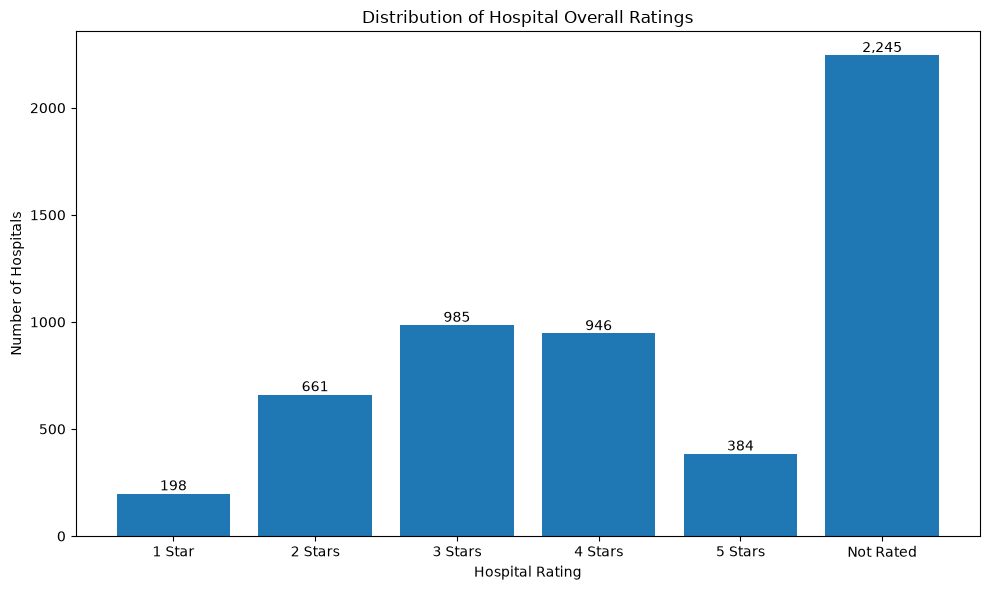

In [51]:
rating_order = [
    "1 Star",
    "2 Stars",
    "3 Stars",
    "4 Stars",
    "5 Stars",
    "Not Rated"
]

rating_counts = (
    df_analysis["Rating Category"]
    .value_counts()
    .reindex(rating_order)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    rating_counts.index,
    rating_counts.values
)

plt.title("Distribution of Hospital Overall Ratings")
plt.xlabel("Hospital Rating")
plt.ylabel("Number of Hospitals")

# Add count above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# 2: Hospital Types.

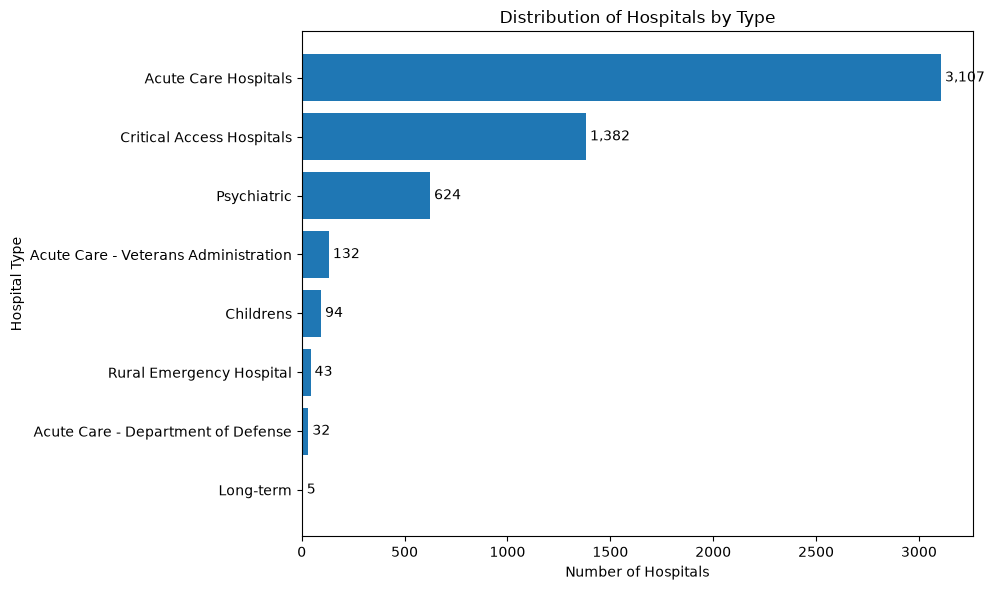

In [52]:
hospital_type_counts = (
    df_analysis["Hospital Type"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    hospital_type_counts.index,
    hospital_type_counts.values
)

plt.title("Distribution of Hospitals by Type")
plt.xlabel("Number of Hospitals")
plt.ylabel("Hospital Type")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {int(width):,}",
        va="center"
    )

plt.tight_layout()
plt.show()

# 3: Hospital Ownership.


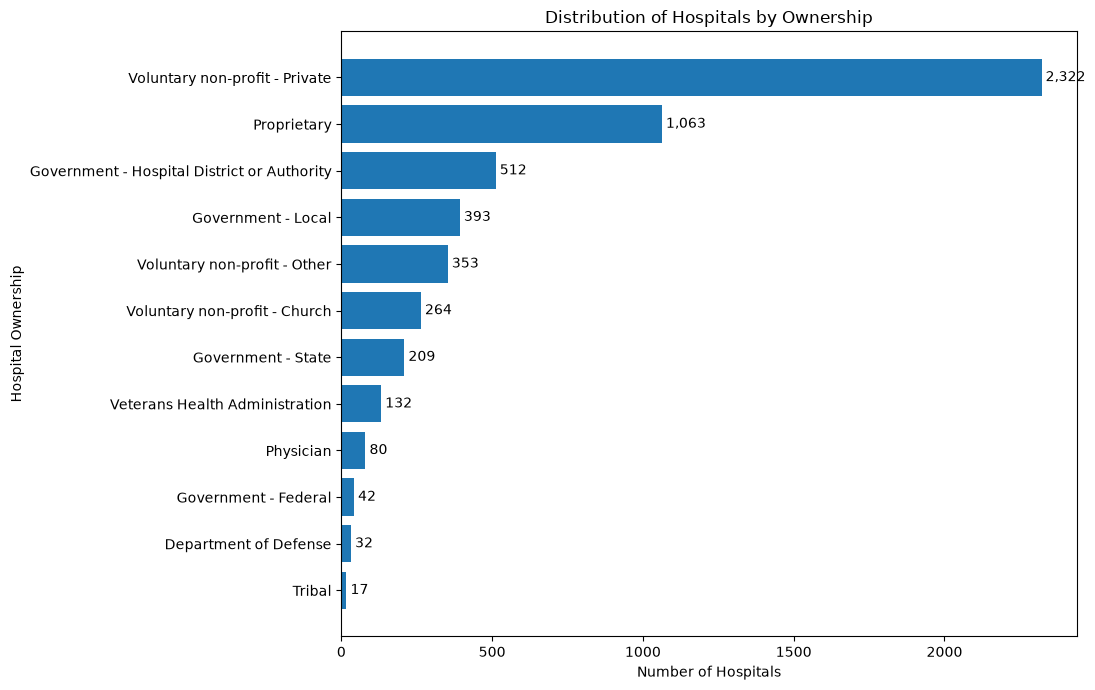

In [53]:
ownership_counts = (
    df_analysis["Hospital Ownership"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    ownership_counts.index,
    ownership_counts.values
)

plt.title("Distribution of Hospitals by Ownership")
plt.xlabel("Number of Hospitals")
plt.ylabel("Hospital Ownership")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {int(width):,}",
        va="center"
    )

plt.tight_layout()
plt.show()

### 4. Average Hospital Rating by State

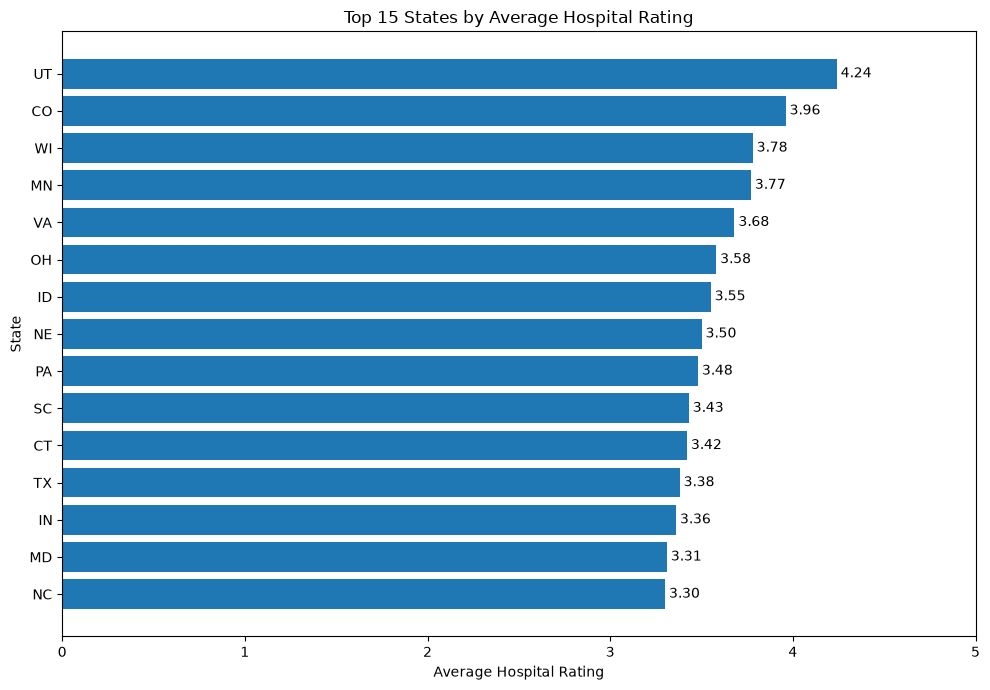

In [54]:
state_rating_plot = (
    state_summary[state_summary["Rated_Hospitals"] >= 20]
    .sort_values("Average_Rating", ascending=False)
    .head(15)
    .sort_values("Average_Rating")
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    state_rating_plot.index,
    state_rating_plot["Average_Rating"]
)

plt.title("Top 15 States by Average Hospital Rating")
plt.xlabel("Average Hospital Rating")
plt.ylabel("State")
plt.xlim(0, 5)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {width:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

### 5. Corewell-Related vs Michigan vs National Average Rating

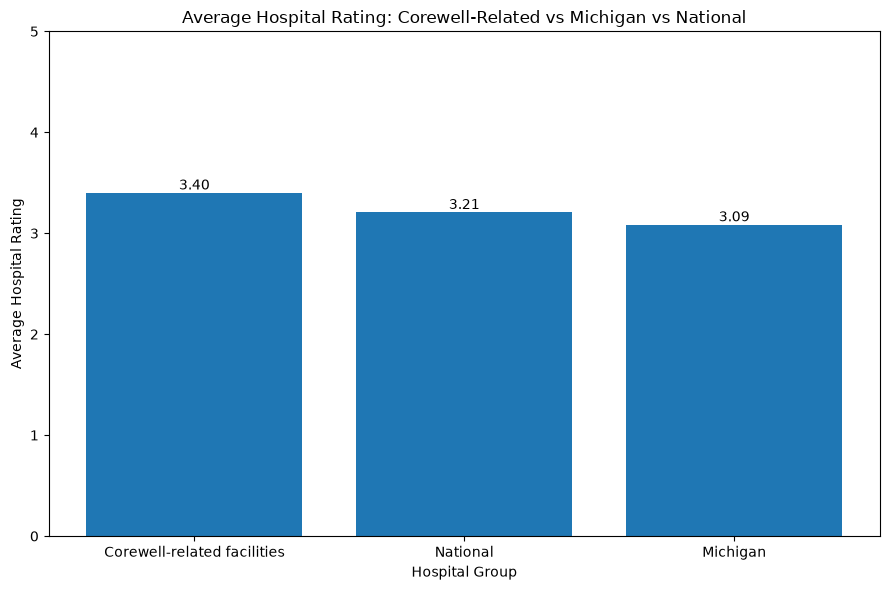

In [55]:
comparison_plot = comparison.sort_values(
    "Average Rating",
    ascending=False
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    comparison_plot["Group"],
    comparison_plot["Average Rating"]
)

plt.title("Average Hospital Rating: Corewell-Related vs Michigan vs National")
plt.xlabel("Hospital Group")
plt.ylabel("Average Hospital Rating")
plt.ylim(0, 5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### 6. Corewell-Related Facility Ratings

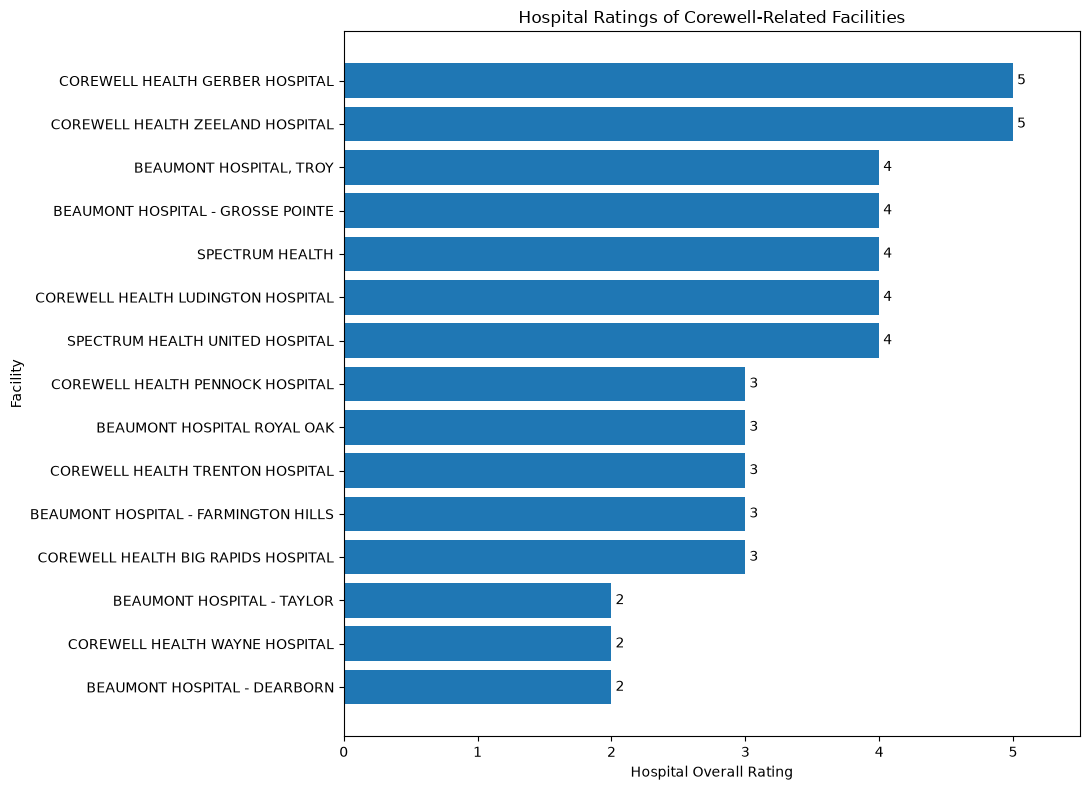

In [56]:
corewell_rated = (
    corewell_group[
        corewell_group["Hospital overall rating"].notna()
    ]
    .sort_values("Hospital overall rating")
)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    corewell_rated["Facility Name"],
    corewell_rated["Hospital overall rating"]
)

plt.title("Hospital Ratings of Corewell-Related Facilities")
plt.xlabel("Hospital Overall Rating")
plt.ylabel("Facility")
plt.xlim(0, 5.5)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {width:.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

## 7. Statistical Analysis and Interpretation

This section applies statistical methods to evaluate patterns observed during exploratory analysis. The analysis examines hospital ratings at the national, Michigan, and Corewell-related levels and tests whether observed differences are statistically meaningful.

Only hospitals with available overall ratings are included in rating-based statistical tests.

**Note:** Only facilities with an available CMS overall hospital rating are shown. 
Two facilities in the candidate Corewell-related group did not have an overall rating 
and were excluded from this chart.

In [59]:
import numpy as np
from scipy import stats

print("Statistical analysis libraries loaded successfully.")

Statistical analysis libraries loaded successfully.


### 7.1 Descriptive Statistics of Hospital Ratings

This analysis compares the distribution of available hospital ratings at the national, Michigan, and candidate Corewell-related levels.

In [60]:
# Create rating samples and remove hospitals without ratings

national_ratings = (
    df_analysis["Hospital overall rating"]
    .dropna()
)

michigan_ratings = (
    michigan["Hospital overall rating"]
    .dropna()
)

corewell_ratings = (
    corewell_group["Hospital overall rating"]
    .dropna()
)

# Build descriptive statistics table

stat_summary = pd.DataFrame({
    "Group": [
        "National",
        "Michigan",
        "Corewell-related"
    ],
    "N": [
        len(national_ratings),
        len(michigan_ratings),
        len(corewell_ratings)
    ],
    "Mean": [
        national_ratings.mean(),
        michigan_ratings.mean(),
        corewell_ratings.mean()
    ],
    "Median": [
        national_ratings.median(),
        michigan_ratings.median(),
        corewell_ratings.median()
    ],
    "Std Dev": [
        national_ratings.std(),
        michigan_ratings.std(),
        corewell_ratings.std()
    ],
    "Min": [
        national_ratings.min(),
        michigan_ratings.min(),
        corewell_ratings.min()
    ],
    "Max": [
        national_ratings.max(),
        michigan_ratings.max(),
        corewell_ratings.max()
    ]
})

stat_summary.round(2)

,Group,N,Mean,Median,Std Dev,Min,Max
0,National,3174,3.21,3.0,1.09,1.0,5.0
1,Michigan,94,3.09,3.0,1.12,1.0,5.0
2,Corewell-related,15,3.40,3.0,0.99,2.0,5.0


#### Interpretation

Among hospitals with available CMS overall ratings, the candidate Corewell-related facilities had the highest observed mean rating (3.40), compared with 3.09 for Michigan and 3.21 nationally. However, all three groups had a median rating of 3.0.

The standard deviations were relatively similar (0.99–1.12), indicating meaningful variation in ratings within each group. The Corewell-related group also had a much smaller sample size (n = 15) than Michigan (n = 94) and the national sample (n = 3,174). Therefore, differences in sample means alone are not sufficient to conclude that the groups differ statistically.

In [ ]:
### 7.2 95% Confidence Intervals for Mean Hospital Ratings

Confidence intervals are calculated to quantify the uncertainty surrounding the estimated mean rating for each group.

In [61]:
def mean_confidence_interval(data, confidence=0.95):
    data = np.asarray(data)
    
    n = len(data)
    mean = np.mean(data)
    sem = stats.sem(data)
    
    margin_error = stats.t.ppf(
        (1 + confidence) / 2,
        df=n - 1
    ) * sem
    
    return mean, mean - margin_error, mean + margin_error


groups = {
    "National": national_ratings,
    "Michigan": michigan_ratings,
    "Corewell-related": corewell_ratings
}

ci_results = []

for group, ratings in groups.items():
    mean, lower, upper = mean_confidence_interval(ratings)
    
    ci_results.append({
        "Group": group,
        "N": len(ratings),
        "Mean": mean,
        "CI Lower": lower,
        "CI Upper": upper
    })

ci_table = pd.DataFrame(ci_results)

ci_table.round(2)

,Group,N,Mean,CI Lower,CI Upper
0,National,3174,3.21,3.17,3.25
1,Michigan,94,3.09,2.86,3.32
2,Corewell-related,15,3.40,2.85,3.95


#### Interpretation

The national mean hospital rating was 3.21 (95% CI: 3.17–3.25), while the Michigan mean was 3.09 (95% CI: 2.86–3.32). The candidate Corewell-related facilities had a higher observed mean rating of 3.40, but the 95% confidence interval was considerably wider (2.85–3.95).

The wider confidence interval for the Corewell-related group reflects its smaller sample size (n = 15). Therefore, although its observed mean is higher than both the Michigan and national averages, considerable uncertainty remains around the estimate. Formal hypothesis testing is needed before concluding that the difference is statistically significant.

### 7.3 Hypothesis Test: Corewell-Related vs Other Michigan Hospitals

To determine whether the observed difference in hospital ratings is statistically meaningful, candidate Corewell-related facilities are compared with other rated Michigan hospitals.

**Null hypothesis (H₀):** There is no difference in mean hospital ratings between the candidate Corewell-related facilities and other Michigan hospitals.

**Alternative hypothesis (H₁):** There is a difference in mean hospital ratings between the candidate Corewell-related facilities and other Michigan hospitals.

A significance level of α = 0.05 is used.

In [63]:
# Facility IDs identified as Corewell-related
corewell_ids = set(corewell_group["Facility ID"])

# Other Michigan hospitals: exclude Corewell-related facilities
other_michigan = michigan[
    ~michigan["Facility ID"].isin(corewell_ids)
].copy()

other_michigan_ratings = (
    other_michigan["Hospital overall rating"]
    .dropna()
)

print("Corewell-related rated facilities:", len(corewell_ratings))
print("Other Michigan rated hospitals:", len(other_michigan_ratings))

print(
    "Corewell-related mean:",
    round(corewell_ratings.mean(), 2)
)

print(
    "Other Michigan mean:",
    round(other_michigan_ratings.mean(), 2)
)

Corewell-related rated facilities: 15
Other Michigan rated hospitals: 79
Corewell-related mean: 3.4
Other Michigan mean: 3.03


### 7.4 Welch's Independent-Samples t-Test

Welch's independent-samples t-test is used to evaluate whether the mean hospital rating of the candidate Corewell-related facilities differs significantly from the mean rating of other Michigan hospitals.

Welch's test is used because the two groups have substantially different sample sizes and it does not require equal population variances.

**H₀:** The mean ratings of the two groups are equal.

**H₁:** The mean ratings of the two groups are different.

**Significance level:** α = 0.05

In [64]:
# Welch's independent-samples t-test

t_stat, p_value = stats.ttest_ind(
    corewell_ratings,
    other_michigan_ratings,
    equal_var=False
)

mean_difference = (
    corewell_ratings.mean()
    - other_michigan_ratings.mean()
)

print(f"Corewell-related mean: {corewell_ratings.mean():.2f}")
print(f"Other Michigan mean: {other_michigan_ratings.mean():.2f}")
print(f"Mean difference: {mean_difference:.2f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    print("Result: Reject the null hypothesis.")
else:
    print("Result: Fail to reject the null hypothesis.")

Corewell-related mean: 3.40
Other Michigan mean: 3.03
Mean difference: 0.37
t-statistic: 1.314
p-value: 0.2025
Result: Fail to reject the null hypothesis.


#### Interpretation

The candidate Corewell-related facilities had a higher observed mean hospital rating (3.40) than other Michigan hospitals (3.03), representing a difference of 0.37 stars.

However, Welch's independent-samples t-test produced a t-statistic of 1.314 and a p-value of 0.2025. Because the p-value is greater than the 0.05 significance level, the null hypothesis was not rejected.

Therefore, the analysis does not provide sufficient statistical evidence that the mean hospital rating of the candidate Corewell-related facilities differs from that of other Michigan hospitals. The observed difference should be interpreted cautiously, particularly because the Corewell-related sample contains only 15 rated facilities.

### 7.5 Effect Size

Cohen's d is calculated to estimate the magnitude of the observed difference in mean hospital ratings between the candidate Corewell-related facilities and other Michigan hospitals.

As a general guideline:

- |d| ≈ 0.2: small effect
- |d| ≈ 0.5: medium effect
- |d| ≈ 0.8: large effect

These thresholds are general conventions and should be interpreted in the context of the data.

In [65]:
# Calculate Cohen's d

n1 = len(corewell_ratings)
n2 = len(other_michigan_ratings)

mean1 = corewell_ratings.mean()
mean2 = other_michigan_ratings.mean()

std1 = corewell_ratings.std(ddof=1)
std2 = other_michigan_ratings.std(ddof=1)

pooled_std = np.sqrt(
    ((n1 - 1) * std1**2 + (n2 - 1) * std2**2)
    / (n1 + n2 - 2)
)

cohens_d = (mean1 - mean2) / pooled_std

print(f"Corewell-related SD: {std1:.2f}")
print(f"Other Michigan SD: {std2:.2f}")
print(f"Cohen's d: {cohens_d:.3f}")

Corewell-related SD: 0.99
Other Michigan SD: 1.14
Cohen's d: 0.334


#### Effect Size Interpretation

Cohen's d was 0.334, indicating a small-to-moderate positive effect. This suggests that the observed difference between the candidate Corewell-related facilities and other Michigan hospitals is modest in magnitude.

However, the Welch's t-test was not statistically significant (p = 0.2025). Therefore, although the Corewell-related facilities had a higher observed mean rating, the available data do not provide sufficient evidence to conclude that a reliable difference exists between the two groups.

### 7.6 Mann–Whitney U Test

Because hospital ratings are discrete 1–5 star values and the Corewell-related sample is relatively small, a Mann–Whitney U test is used as a non-parametric comparison between candidate Corewell-related facilities and other Michigan hospitals.

**H₀:** The rating distributions of the two groups do not differ.

**H₁:** The rating distributions of the two groups differ.

**Significance level:** α = 0.05

In [66]:
u_stat, mw_p_value = stats.mannwhitneyu(
    corewell_ratings,
    other_michigan_ratings,
    alternative="two-sided"
)

print(f"Mann-Whitney U statistic: {u_stat:.2f}")
print(f"p-value: {mw_p_value:.4f}")

if mw_p_value < 0.05:
    print("Result: Reject the null hypothesis.")
else:
    print("Result: Fail to reject the null hypothesis.")

Mann-Whitney U statistic: 694.50
p-value: 0.2782
Result: Fail to reject the null hypothesis.


#### Mann–Whitney U Test Interpretation

The Mann–Whitney U test produced U = 694.50 and p = 0.2782. Since the p-value is greater than the 0.05 significance level, the null hypothesis was not rejected.

This result is consistent with Welch's t-test. Both tests indicate that the available data do not provide sufficient statistical evidence of a difference between the ratings of the candidate Corewell-related facilities and other Michigan hospitals.

Although the Corewell-related facilities had a higher observed mean rating (3.40 vs. 3.03) and Cohen's d indicated a small-to-moderate effect (d = 0.334), the difference was not statistically significant in this sample.

### 7.7 Michigan vs Other U.S. Hospitals

This analysis compares rated Michigan hospitals with rated hospitals outside Michigan to determine whether the observed difference in mean ratings is statistically significant.

In [67]:
other_us_ratings = (
    df_analysis.loc[
        df_analysis["State"] != "MI",
        "Hospital overall rating"
    ]
    .dropna()
)

print("Michigan rated hospitals:", len(michigan_ratings))
print("Other U.S. rated hospitals:", len(other_us_ratings))

print(f"Michigan mean: {michigan_ratings.mean():.2f}")
print(f"Other U.S. mean: {other_us_ratings.mean():.2f}")

t_stat_mi, p_value_mi = stats.ttest_ind(
    michigan_ratings,
    other_us_ratings,
    equal_var=False
)

print(f"Mean difference: {michigan_ratings.mean() - other_us_ratings.mean():.2f}")
print(f"t-statistic: {t_stat_mi:.3f}")
print(f"p-value: {p_value_mi:.4f}")

if p_value_mi < 0.05:
    print("Result: Reject the null hypothesis.")
else:
    print("Result: Fail to reject the null hypothesis.")

Michigan rated hospitals: 94
Other U.S. rated hospitals: 3080
Michigan mean: 3.09
Other U.S. mean: 3.21
Mean difference: -0.13
t-statistic: -1.069
p-value: 0.2877
Result: Fail to reject the null hypothesis.


#### Michigan vs Other U.S. Hospitals Interpretation

Rated Michigan hospitals had an average overall rating of 3.09, compared with 3.21 for rated hospitals outside Michigan. The observed mean difference was -0.13 stars.

Welch's independent-samples t-test produced t = -1.069 and p = 0.2877. Since the p-value is greater than the 0.05 significance level, the null hypothesis was not rejected.

Therefore, the available data do not provide sufficient statistical evidence that the mean overall hospital rating in Michigan differs from the mean rating of hospitals outside Michigan.

### 7.8 Statistical Analysis Summary

The statistical analysis produced the following key findings:

- The national mean rating among rated hospitals was 3.21 (95% CI: 3.17–3.25).
- Michigan's mean rating was 3.09 (95% CI: 2.86–3.32).
- The candidate Corewell-related group had the highest observed mean rating at 3.40 (95% CI: 2.85–3.95), but its confidence interval was wider because only 15 facilities had available ratings.
- Candidate Corewell-related facilities averaged 0.37 stars higher than other Michigan hospitals (3.40 vs. 3.03).
- Welch's t-test found that this difference was not statistically significant (t = 1.314, p = 0.2025).
- The Mann–Whitney U test reached the same general conclusion (U = 694.50, p = 0.2782).
- Cohen's d was 0.334, indicating a small-to-moderate observed effect.
- Michigan hospitals averaged 0.13 stars lower than hospitals outside Michigan (3.09 vs. 3.21), but this difference was also not statistically significant (t = -1.069, p = 0.2877).

#### Overall Interpretation

The descriptive results show differences in average hospital ratings, particularly the higher observed mean among the candidate Corewell-related facilities. However, the inferential tests do not provide sufficient evidence at the 0.05 significance level to conclude that these differences represent statistically reliable differences between the groups.

The results should therefore be interpreted as descriptive patterns rather than evidence that Corewell affiliation or Michigan location causes differences in hospital performance.

Important limitations include the small Corewell-related sample, missing overall ratings for many hospitals, the discrete 1–5 star rating scale, and the use of facility-name matching to identify the candidate Corewell-related group.